In [183]:
from pathlib import Path
import mne
import numpy as np
import matplotlib.pyplot as plt

# Notebook is inside ML_PROJECT1/notebooks,
# so move one level up to the project root.
PROJECT_ROOT = Path.cwd().parent

edf_path = PROJECT_ROOT / "data" / "CHB-MIT" / "chb01" / "chb01_03.edf"

print("Project root:", PROJECT_ROOT)
print("EDF:", edf_path)
print("Exists:", edf_path.exists())

raw = mne.io.read_raw_edf(
    edf_path,
    preload=True,
    verbose=False
)

print("\nRecording:")
print(raw)
print("\nSampling frequency:", raw.info["sfreq"])
print("Channels:", len(raw.ch_names))
print("Duration:", raw.times[-1], "seconds")

Project root: c:\Users\Soumya Bhardwaj\ML_PROJECT1
EDF: c:\Users\Soumya Bhardwaj\ML_PROJECT1\data\CHB-MIT\chb01\chb01_03.edf
Exists: True

Recording:
<RawEDF | chb01_03.edf, 23 x 921600 (3600.0 s), ~161.7 MiB, data loaded>

Sampling frequency: 256.0
Channels: 23
Duration: 3599.99609375 seconds


C:\Users\Soumya Bhardwaj\AppData\Local\Temp\ipykernel_30336\1020820749.py:16: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(


In [184]:
from pathlib import Path
import mne
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent

edf_path = PROJECT_ROOT / "data" / "CHB-MIT" / "chb01" / "chb01_03.edf"

print("Project root:", PROJECT_ROOT)
print("EDF:", edf_path)
print("Exists:", edf_path.exists())

raw = mne.io.read_raw_edf(
    edf_path,
    preload=True,
    verbose=False
)

print("\nRecording:")
print(raw)
print("\nSampling frequency:", raw.info["sfreq"])
print("Channels:", len(raw.ch_names))
print("Duration:", raw.times[-1], "seconds")

Project root: c:\Users\Soumya Bhardwaj\ML_PROJECT1
EDF: c:\Users\Soumya Bhardwaj\ML_PROJECT1\data\CHB-MIT\chb01\chb01_03.edf
Exists: True


C:\Users\Soumya Bhardwaj\AppData\Local\Temp\ipykernel_30336\1357760806.py:14: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(



Recording:
<RawEDF | chb01_03.edf, 23 x 921600 (3600.0 s), ~161.7 MiB, data loaded>

Sampling frequency: 256.0
Channels: 23
Duration: 3599.99609375 seconds


In [185]:
raw_filtered = raw.copy()

raw_filtered.filter(
    l_freq=0.5,
    h_freq=70.0,
    picks="eeg",
    verbose=False
)

print("Band-pass filtering complete.")
print("Frequency range: 0.5–70 Hz")

Band-pass filtering complete.
Frequency range: 0.5–70 Hz


Effective window size : 8.000 (s)
Plotting power spectral density (dB=True).


c:\Users\Soumya Bhardwaj\ML_PROJECT1\.venv\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


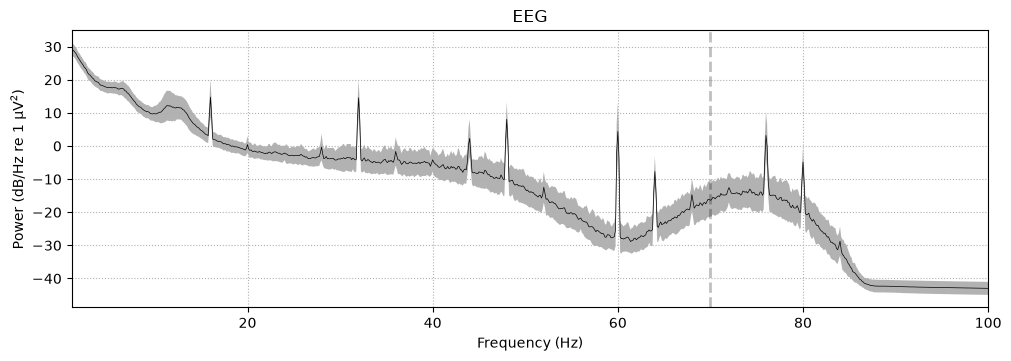

In [186]:
psd = raw_filtered.compute_psd(
    fmin=1,
    fmax=100,
    picks="eeg"
)

psd.plot(
    average=True,
    dB=True
)

In [187]:
# Defining the seizure interval from the CHB-MIT annotation
seizure_start = 2996
seizure_end = 3036

# Window configuration
window_size = 10       # seconds
step_size = 10         # seconds, no overlap for now

print("Seizure:", seizure_start, "to", seizure_end, "seconds")
print("Window size:", window_size, "seconds")
print("Step size:", step_size, "seconds")

Seizure: 2996 to 3036 seconds
Window size: 10 seconds
Step size: 10 seconds


In [188]:
# Labeling rule
MIN_SEIZURE_OVERLAP = 0.50

def get_window_label(window_start, window_end, seizure_start, seizure_end):
    """
    Assign a label to an EEG window based on its overlap
    with the annotated seizure interval.

    Returns:
        1 = seizure
        0 = non-seizure
        None = ambiguous / discard
    """
    
    overlap_start = max(window_start, seizure_start)
    overlap_end = min(window_end, seizure_end)

    overlap = max(0, overlap_end - overlap_start)
    window_duration = window_end - window_start

    overlap_ratio = overlap / window_duration

    if overlap_ratio >= MIN_SEIZURE_OVERLAP:
        return 1
    elif overlap_ratio == 0:
        return 0
    else:
        return None


# Test the rule
test_windows = [
    (2980, 2990),
    (2990, 3000),
    (3000, 3010),
    (3010, 3020),
    (3020, 3030),
    (3030, 3040),
    (3040, 3050),
]

for start, end in test_windows:
    label = get_window_label(
        start,
        end,
        seizure_start,
        seizure_end
    )

    print(f"{start:4d}-{end:4d} s  →  {label}")

2980-2990 s  →  0
2990-3000 s  →  None
3000-3010 s  →  1
3010-3020 s  →  1
3020-3030 s  →  1
3030-3040 s  →  1
3040-3050 s  →  0


In [189]:
# Generate 10-second windows from the recording

sfreq = raw_filtered.info["sfreq"]

window_samples = int(window_size * sfreq)
step_samples = int(step_size * sfreq)

windows = []
labels = []
window_times = []

n_samples = raw_filtered.n_times

for start_sample in range(0, n_samples - window_samples + 1, step_samples):

    end_sample = start_sample + window_samples

    start_time = start_sample / sfreq
    end_time = end_sample / sfreq

    label = get_window_label(
        start_time,
        end_time,
        seizure_start,
        seizure_end
    )

    # Keep only clearly labelled windows
    if label is not None:
        window = raw_filtered.get_data(
            start=start_sample,
            stop=end_sample
        )

        windows.append(window)
        labels.append(label)
        window_times.append((start_time, end_time))

windows = np.array(windows)
labels = np.array(labels)

print("Windows shape:", windows.shape)
print("Labels shape:", labels.shape)
print("Seizure windows:", np.sum(labels == 1))
print("Non-seizure windows:", np.sum(labels == 0))

Windows shape: (359, 23, 2560)
Labels shape: (359,)
Seizure windows: 4
Non-seizure windows: 355


In [190]:
print("One window shape:", windows[0].shape)
print("First window time:", window_times[0])
print("First window label:", labels[0])

print("\nLast window time:", window_times[-1])
print("Last window label:", labels[-1])

One window shape: (23, 2560)
First window time: (0.0, 10.0)
First window label: 0

Last window time: (3590.0, 3600.0)
Last window label: 0


In [191]:
seizure_indices = np.where(labels == 1)[0]

print("Seizure window indices:", seizure_indices)

for idx in seizure_indices:
    print(
        f"Window {idx}: "
        f"{window_times[idx][0]:.0f}-{window_times[idx][1]:.0f} s"
    )

Seizure window indices: [299 300 301 302]
Window 299: 3000-3010 s
Window 300: 3010-3020 s
Window 301: 3020-3030 s
Window 302: 3030-3040 s


In [192]:
import scipy
print(scipy.__version__)

1.17.1


In [193]:
import pandas as pd
from scipy.signal import welch

# Frequency bands
FREQUENCY_BANDS = {
    "delta": (0.5, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
    "gamma": (30, 70),
}


def extract_channel_features(signal, sfreq):
    """
    Extract interpretable time- and frequency-domain
    features from one EEG channel/window.
    """

    features = {}

    # -------------------------
    # Time-domain features
    # -------------------------

    features["mean"] = np.mean(signal)

    features["std"] = np.std(signal)

    features["variance"] = np.var(signal)

    features["rms"] = np.sqrt(np.mean(signal ** 2))

    # Line length
    features["line_length"] = np.sum(np.abs(np.diff(signal)))

    # -------------------------
    # Frequency-domain features
    # -------------------------

    frequencies, power = welch(
        signal,
        fs=sfreq,
        nperseg=min(len(signal), int(sfreq * 2))
    )

    total_power = np.trapezoid(power, frequencies)

    for band_name, (low, high) in FREQUENCY_BANDS.items():

        band_mask = (
            (frequencies >= low) &
            (frequencies < high)
        )

        band_power = np.trapezoid(
            power[band_mask],
            frequencies[band_mask]
        )

        # Relative power
        if total_power > 0:
            relative_power = band_power / total_power
        else:
            relative_power = 0

        features[f"{band_name}_relative_power"] = relative_power

    return features

In [194]:
sfreq = raw_filtered.info["sfreq"]

test_features = extract_channel_features(
    windows[0][0],
    sfreq
)

print("Number of features:", len(test_features))

for name, value in test_features.items():
    print(f"{name:25s}: {value:.6e}")

Number of features: 10
mean                     : 9.445993e-07
std                      : 2.660297e-05
variance                 : 7.077178e-10
rms                      : 2.661973e-05
line_length              : 1.088091e-02
delta_relative_power     : 4.552560e-01
theta_relative_power     : 1.586462e-01
alpha_relative_power     : 2.703360e-01
beta_relative_power      : 3.399464e-02
gamma_relative_power     : 1.087319e-02


In [195]:
all_features = []

sfreq = raw_filtered.info["sfreq"]

for window_idx, window in enumerate(windows):

    window_features = {
        "window_index": window_idx,
        "label": labels[window_idx]
    }

    for channel_idx, channel_name in enumerate(raw_filtered.ch_names):

        channel_features = extract_channel_features(
            window[channel_idx],
            sfreq
        )

        for feature_name, value in channel_features.items():

            column_name = f"{channel_name}_{feature_name}"

            window_features[column_name] = value

    all_features.append(window_features)


features_df = pd.DataFrame(all_features)

print("Feature matrix shape:", features_df.shape)
print("Number of windows:", len(features_df))
print("Number of feature columns:", len(features_df.columns) - 2)

Feature matrix shape: (359, 232)
Number of windows: 359
Number of feature columns: 230


In [196]:
print(features_df.head())
print("\nMissing values:", features_df.isna().sum().sum())
print("Infinite values:", np.isinf(features_df.select_dtypes(include=np.number)).sum().sum())

print("\nClass distribution:")
print(features_df["label"].value_counts())

print("\nClass percentages:")
print(features_df["label"].value_counts(normalize=True) * 100)

   window_index  label   FP1-F7_mean  FP1-F7_std  FP1-F7_variance  FP1-F7_rms  \
0             0      0  9.445993e-07    0.000027     7.077178e-10    0.000027   
1             1      0 -1.285704e-08    0.000030     9.166091e-10    0.000030   
2             2      0  4.427070e-08    0.000036     1.332046e-09    0.000036   
3             3      0 -2.897399e-07    0.000067     4.516309e-09    0.000067   
4             4      0 -2.469186e-07    0.000026     6.619004e-10    0.000026   

   FP1-F7_line_length  FP1-F7_delta_relative_power  \
0            0.010881                     0.455256   
1            0.011539                     0.428037   
2            0.012165                     0.525611   
3            0.025848                     0.642910   
4            0.008782                     0.418315   

   FP1-F7_theta_relative_power  FP1-F7_alpha_relative_power  ...  \
0                     0.158646                     0.270336  ...   
1                     0.150251                     0

In [197]:
results_dir = PROJECT_ROOT / "results"
results_dir.mkdir(exist_ok=True)

features_path = results_dir / "features_chb01_03.csv"

features_df.to_csv(features_path, index=False)

print("Saved:", features_path)
print("File exists:", features_path.exists())
print("Size:", features_path.stat().st_size / 1024, "KB")

Saved: c:\Users\Soumya Bhardwaj\ML_PROJECT1\results\features_chb01_03.csv
File exists: True
Size: 1709.15625 KB


In [198]:
# Separate seizure and non-seizure windows
seizure_df = features_df[features_df["label"] == 1]
nonseizure_df = features_df[features_df["label"] == 0]

print("Seizure windows:", len(seizure_df))
print("Non-seizure windows:", len(nonseizure_df))


# Look at a few representative features from FP1-F7
features_to_check = [
    "FP1-F7_std",
    "FP1-F7_rms",
    "FP1-F7_line_length",
    "FP1-F7_delta_relative_power",
    "FP1-F7_theta_relative_power",
    "FP1-F7_alpha_relative_power",
    "FP1-F7_beta_relative_power",
    "FP1-F7_gamma_relative_power",
]

comparison = pd.DataFrame({
    "Feature": features_to_check,
    "Non-seizure mean": [
        nonseizure_df[f].mean() for f in features_to_check
    ],
    "Seizure mean": [
        seizure_df[f].mean() for f in features_to_check
    ],
})

comparison

Seizure windows: 4
Non-seizure windows: 355


,Feature,Non-seizure mean,Seizure mean
0,FP1-F7_std,0.000035,0.000114
1,FP1-F7_rms,0.000035,0.000114
2,FP1-F7_line_length,0.010571,0.045030
3,FP1-F7_delta_relative_power,0.591303,0.739208
4,FP1-F7_theta_relative_power,0.153551,0.098629
5,FP1-F7_alpha_relative_power,0.082148,0.007936
6,FP1-F7_beta_relative_power,0.044595,0.024327
7,FP1-F7_gamma_relative_power,0.022528,0.047473


In [199]:
print("raw_filtered exists:", "raw_filtered" in globals())
print("windows exists:", "windows" in globals())
print("labels exists:", "labels" in globals())

raw_filtered exists: True
windows exists: True
labels exists: True


In [200]:
from pathlib import Path
import numpy as np
import pandas as pd
import mne

# Project root
PROJECT_ROOT = Path.cwd().parent

# EDF file
edf_path = PROJECT_ROOT / "data" / "CHB-MIT" / "chb01" / "chb01_03.edf"

print("Project root:", PROJECT_ROOT)
print("EDF:", edf_path)
print("Exists:", edf_path.exists())

raw = mne.io.read_raw_edf(
    edf_path,
    preload=True,
    verbose=False
)

print("\nSampling frequency:", raw.info["sfreq"], "Hz")
print("Channels:", len(raw.ch_names))
print("Duration:", raw.times[-1], "seconds")

Project root: c:\Users\Soumya Bhardwaj\ML_PROJECT1
EDF: c:\Users\Soumya Bhardwaj\ML_PROJECT1\data\CHB-MIT\chb01\chb01_03.edf
Exists: True

Sampling frequency: 256.0 Hz
Channels: 23
Duration: 3599.99609375 seconds


C:\Users\Soumya Bhardwaj\AppData\Local\Temp\ipykernel_30336\3282818937.py:16: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(


In [201]:
raw_filtered = raw.copy()

raw_filtered.filter(
    l_freq=0.5,
    h_freq=70.0,
    picks="eeg",
    verbose=False
)

print("Band-pass filtering complete.")
print("Frequency range: 0.5–70 Hz")

Band-pass filtering complete.
Frequency range: 0.5–70 Hz


In [202]:
# Compare one non-seizure window with one seizure window

non_seizure_idx = 298
seizure_idx = 299

non_seizure_window = windows[non_seizure_idx]
seizure_window = windows[seizure_idx]

print("Non-seizure window:")
print("Index:", non_seizure_idx)
print("Time:", window_times[non_seizure_idx])
print("Label:", labels[non_seizure_idx])

print("\nSeizure window:")
print("Index:", seizure_idx)
print("Time:", window_times[seizure_idx])
print("Label:", labels[seizure_idx])

print("\nWindow shape:", non_seizure_window.shape)

Non-seizure window:
Index: 298
Time: (2980.0, 2990.0)
Label: 0

Seizure window:
Index: 299
Time: (3000.0, 3010.0)
Label: 1

Window shape: (23, 2560)


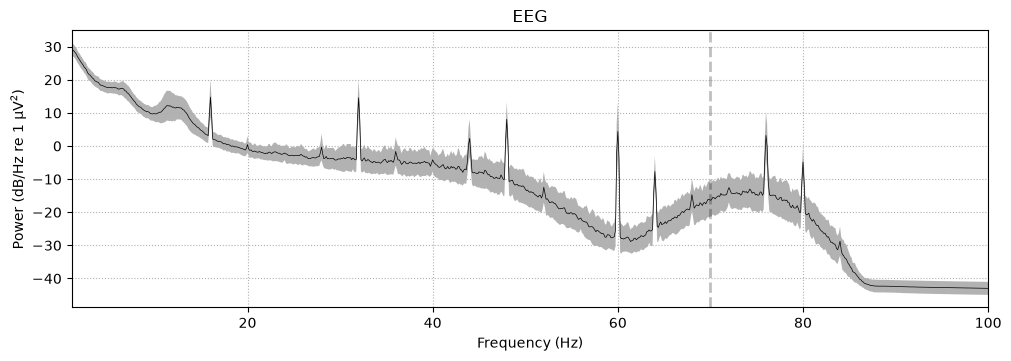

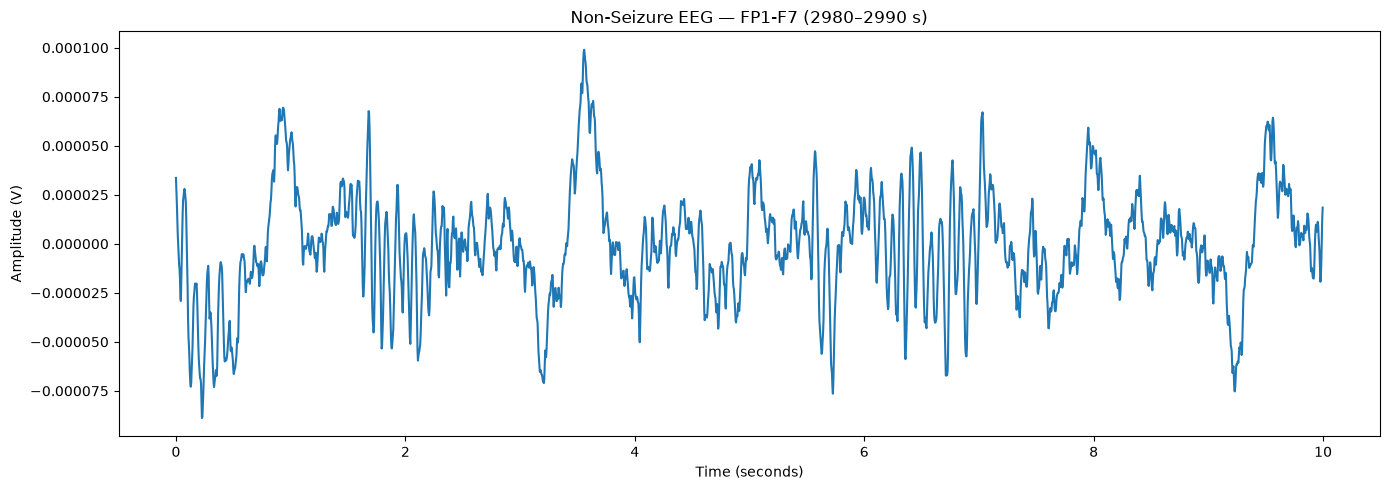

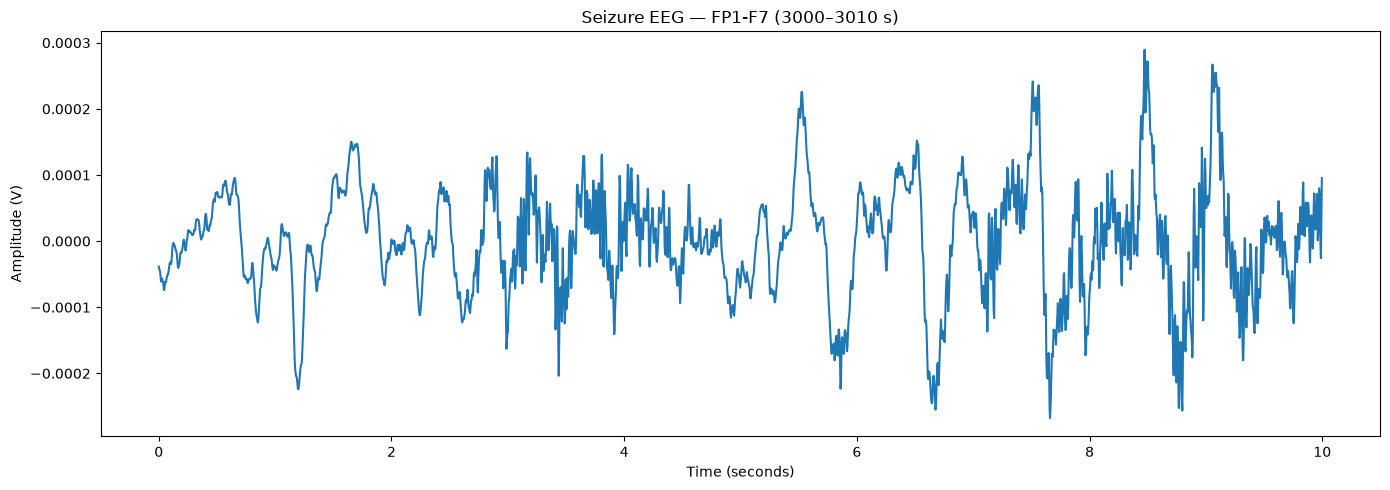

In [203]:
import matplotlib.pyplot as plt

channel_idx = raw_filtered.ch_names.index("FP1-F7")

non_seizure_signal = non_seizure_window[channel_idx]
seizure_signal = seizure_window[channel_idx]

time = np.arange(len(non_seizure_signal)) / raw_filtered.info["sfreq"]

plt.figure(figsize=(14, 5))

plt.plot(time, non_seizure_signal)

plt.title("Non-Seizure EEG — FP1-F7 (2980–2990 s)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (V)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))

plt.plot(time, seizure_signal)

plt.title("Seizure EEG — FP1-F7 (3000–3010 s)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (V)")
plt.tight_layout()
plt.show()

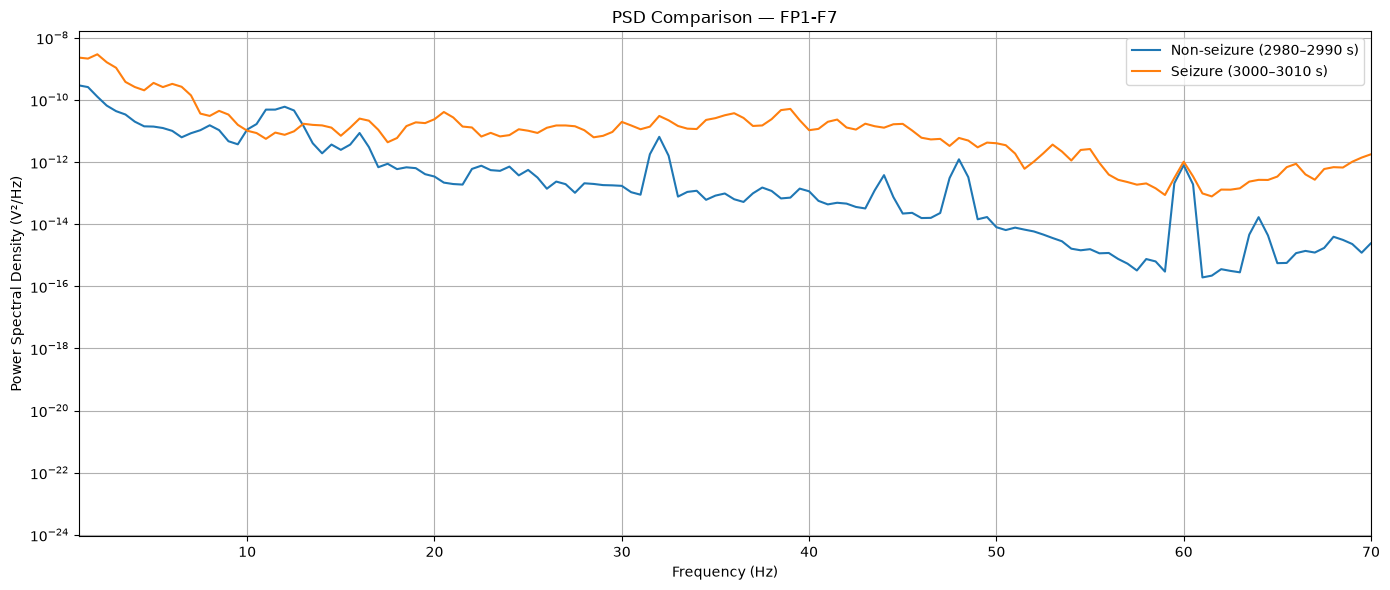

In [204]:
from scipy.signal import welch
import matplotlib.pyplot as plt

sfreq = raw_filtered.info["sfreq"]

# Calculate PSD for the same FP1-F7 windows
freq_non, psd_non = welch(
    non_seizure_signal,
    fs=sfreq,
    nperseg=sfreq * 2
)

freq_seiz, psd_seiz = welch(
    seizure_signal,
    fs=sfreq,
    nperseg=sfreq * 2
)

# Plot both on the same graph
plt.figure(figsize=(14, 6))

plt.semilogy(
    freq_non,
    psd_non,
    label="Non-seizure (2980–2990 s)"
)

plt.semilogy(
    freq_seiz,
    psd_seiz,
    label="Seizure (3000–3010 s)"
)

plt.xlim(1, 70)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density (V²/Hz)")
plt.title("PSD Comparison — FP1-F7")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [205]:
from scipy.signal import welch
import numpy as np
import matplotlib.pyplot as plt

sfreq = raw_filtered.info["sfreq"]

# PSD for the same two FP1-F7 windows
freq_non, psd_non = welch(
    non_seizure_signal,
    fs=sfreq,
    nperseg=int(sfreq * 2)
)

freq_seiz, psd_seiz = welch(
    seizure_signal,
    fs=sfreq,
    nperseg=int(sfreq * 2)
)

# Keep only frequencies between 1 and 70 Hz
mask_non = (freq_non >= 1) & (freq_non <= 70)
mask_seiz = (freq_seiz >= 1) & (freq_seiz <= 70)

# Log-transform
log_freq_non = np.log10(freq_non[mask_non])
log_psd_non = np.log10(psd_non[mask_non])

log_freq_seiz = np.log10(freq_seiz[mask_seiz])
log_psd_seiz = np.log10(psd_seiz[mask_seiz])

# Linear regression in log-log space
slope_non, intercept_non = np.polyfit(
    log_freq_non,
    log_psd_non,
    1
)

slope_seiz, intercept_seiz = np.polyfit(
    log_freq_seiz,
    log_psd_seiz,
    1
)

print("Spectral slope comparison")
print("--------------------------")
print(f"Non-seizure slope: {slope_non:.4f}")
print(f"Seizure slope:     {slope_seiz:.4f}")

Spectral slope comparison
--------------------------
Non-seizure slope: -3.4663
Seizure slope:     -2.0145


In [206]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# -----------------------------------------
# Noise configuration
# -----------------------------------------

sfreq = 256.0
duration = 10.0
n_samples = int(sfreq * duration)

rng = np.random.default_rng(42)

# Frequency range for comparison
fmin = 1
fmax = 70


# -----------------------------------------
# Generate white noise
# -----------------------------------------

white_noise = rng.normal(
    0,
    1,
    n_samples
)


# -----------------------------------------
# Generate colored noise using FFT
# -----------------------------------------

def generate_colored_noise(
    n_samples,
    sfreq,
    beta,
    rng
):
    """
    Generate noise with approximately

        PSD ∝ 1 / f^beta

    beta = 0 → white
    beta = 1 → pink
    beta = 3 → black
    """

    frequencies = np.fft.rfftfreq(
        n_samples,
        d=1 / sfreq
    )

    # Start with random Fourier coefficients
    spectrum = (
        rng.normal(size=len(frequencies))
        + 1j * rng.normal(size=len(frequencies))
    )

    # Avoid division by zero at DC
    scaling = np.ones_like(frequencies)

    nonzero = frequencies > 0

    scaling[nonzero] = (
        frequencies[nonzero] ** (-beta / 2)
    )

    spectrum *= scaling

    # Remove DC component
    spectrum[0] = 0

    # Convert back to time domain
    noise = np.fft.irfft(
        spectrum,
        n=n_samples
    )

    # Normalize
    noise = (
        noise - np.mean(noise)
    ) / np.std(noise)

    return noise


pink_noise = generate_colored_noise(
    n_samples,
    sfreq,
    beta=1,
    rng=rng
)

black_noise = generate_colored_noise(
    n_samples,
    sfreq,
    beta=3,
    rng=rng
)


print("Noise generation complete.")
print("Sampling frequency:", sfreq, "Hz")
print("Duration:", duration, "seconds")
print("Samples:", n_samples)

Noise generation complete.
Sampling frequency: 256.0 Hz
Duration: 10.0 seconds
Samples: 2560


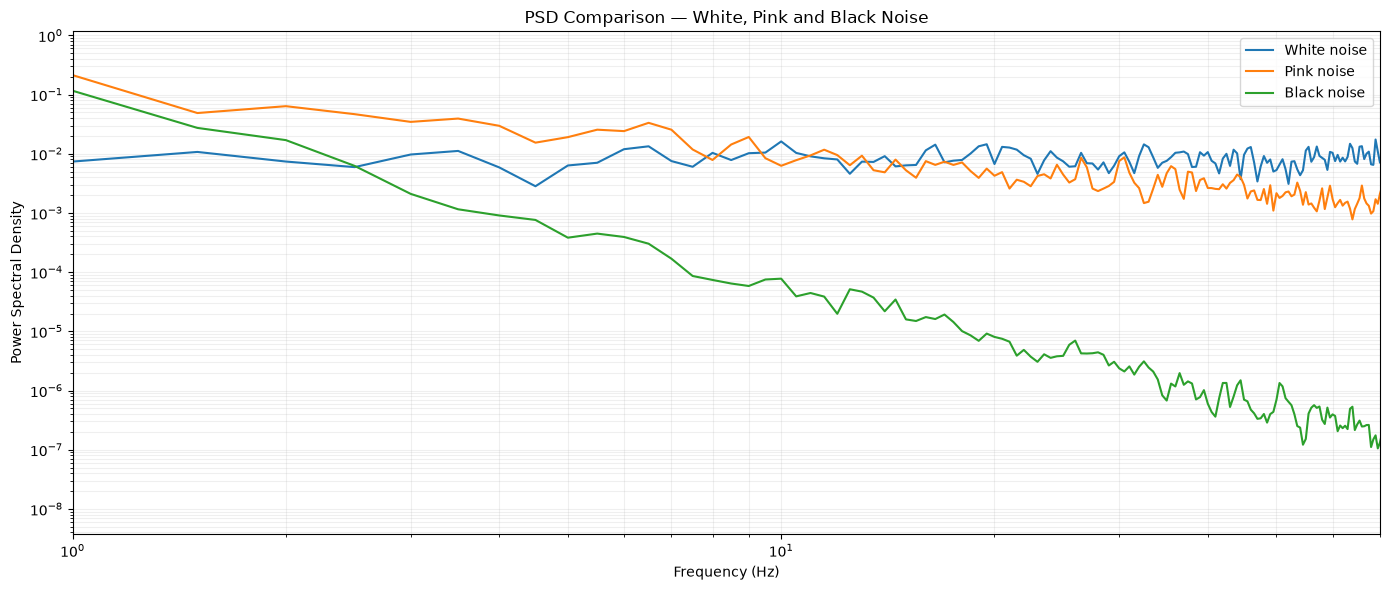

In [207]:
# -----------------------------------------
# Calculate PSD using Welch's method
# -----------------------------------------

freq_white, psd_white = welch(
    white_noise,
    fs=sfreq,
    nperseg=int(sfreq * 2)
)

freq_pink, psd_pink = welch(
    pink_noise,
    fs=sfreq,
    nperseg=int(sfreq * 2)
)

freq_black, psd_black = welch(
    black_noise,
    fs=sfreq,
    nperseg=int(sfreq * 2)
)


# -----------------------------------------
# Plot noise PSDs
# -----------------------------------------

plt.figure(figsize=(14, 6))

plt.loglog(
    freq_white,
    psd_white,
    label="White noise"
)

plt.loglog(
    freq_pink,
    psd_pink,
    label="Pink noise"
)

plt.loglog(
    freq_black,
    psd_black,
    label="Black noise"
)

plt.xlim(fmin, fmax)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density")

plt.title(
    "PSD Comparison — White, Pink and Black Noise"
)

plt.legend()
plt.grid(True, which="both", alpha=0.2)

plt.tight_layout()
plt.show()

In [208]:
from scipy.stats import linregress
import numpy as np

def calculate_spectral_slope(freq, psd, fmin=1, fmax=70):
    """
    Calculate spectral slope in log-log space.
    """

    mask = (
        (freq >= fmin) &
        (freq <= fmax) &
        (psd > 0)
    )

    log_freq = np.log10(freq[mask])
    log_psd = np.log10(psd[mask])

    slope, intercept, r_value, p_value, std_err = linregress(
        log_freq,
        log_psd
    )

    return slope


white_slope = calculate_spectral_slope(
    freq_white,
    psd_white
)

pink_slope = calculate_spectral_slope(
    freq_pink,
    psd_pink
)

black_slope = calculate_spectral_slope(
    freq_black,
    psd_black
)

print("Spectral slope comparison")
print("--------------------------")
print(f"White noise: {white_slope:.4f}")
print(f"Pink noise:  {pink_slope:.4f}")
print(f"Black noise: {black_slope:.4f}")

Spectral slope comparison
--------------------------
White noise: 0.0047
Pink noise:  -1.0343
Black noise: -3.0370


In [209]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------
# Stochastic Resonance — canonical model
# -----------------------------------------

# Simulation parameters
dt = 0.01
duration = 500       # seconds
sfreq = 1 / dt

# Weak periodic input
signal_amplitude = 0.20
signal_frequency = 0.05   # Hz

# Bistable system parameters
a = 1.0
b = 1.0

# Noise intensities to test
noise_levels = np.linspace(0.01, 0.30, 20)

rng = np.random.default_rng(42)

n_samples = int(duration / dt)

time = np.arange(n_samples) * dt

print("Stochastic Resonance simulation")
print("--------------------------------")
print("Duration:", duration, "seconds")
print("Sampling frequency:", sfreq, "Hz")
print("Signal amplitude:", signal_amplitude)
print("Signal frequency:", signal_frequency, "Hz")
print("Number of noise levels:", len(noise_levels))

Stochastic Resonance simulation
--------------------------------
Duration: 500 seconds
Sampling frequency: 100.0 Hz
Signal amplitude: 0.2
Signal frequency: 0.05 Hz
Number of noise levels: 20


In [210]:
def simulate_bistable_system(
    noise_intensity,
    time,
    dt,
    signal_amplitude,
    signal_frequency,
    a=1.0,
    b=1.0,
    rng=None
):
    """
    Simulate an overdamped bistable nonlinear system:

        dx/dt = ax - bx^3 + A cos(2πft) + noise

    The system has two stable states.
    """

    if rng is None:
        rng = np.random.default_rng()

    x = np.zeros(len(time))

    # Start in one stable state
    x[0] = -1.0

    for i in range(len(time) - 1):

        periodic_signal = (
            signal_amplitude *
            np.cos(2 * np.pi * signal_frequency * time[i])
        )

        deterministic_part = (
            a * x[i]
            - b * x[i] ** 3
            + periodic_signal
        )

        stochastic_part = (
            np.sqrt(2 * noise_intensity * dt)
            * rng.normal()
        )

        x[i + 1] = (
            x[i]
            + deterministic_part * dt
            + stochastic_part
        )

    return x

In [211]:
responses = []

for noise in noise_levels:

    output = simulate_bistable_system(
        noise_intensity=noise,
        time=time,
        dt=dt,
        signal_amplitude=signal_amplitude,
        signal_frequency=signal_frequency,
        a=a,
        b=b,
        rng=rng
    )

    # Remove initial transient
    start = int(0.2 * len(output))

    output_segment = output[start:]
    time_segment = time[start:]

    # Measure response at the driving frequency
    reference = np.cos(
        2 * np.pi *
        signal_frequency *
        time_segment
    )

    response = abs(
        np.mean(
            output_segment * reference
        )
    )

    responses.append(response)


responses = np.array(responses)

print("SR simulation complete.")
print("Maximum response:", responses.max())
print(
    "Optimal noise intensity:",
    noise_levels[np.argmax(responses)]
)

SR simulation complete.
Maximum response: 0.16867700947429154
Optimal noise intensity: 0.2236842105263158


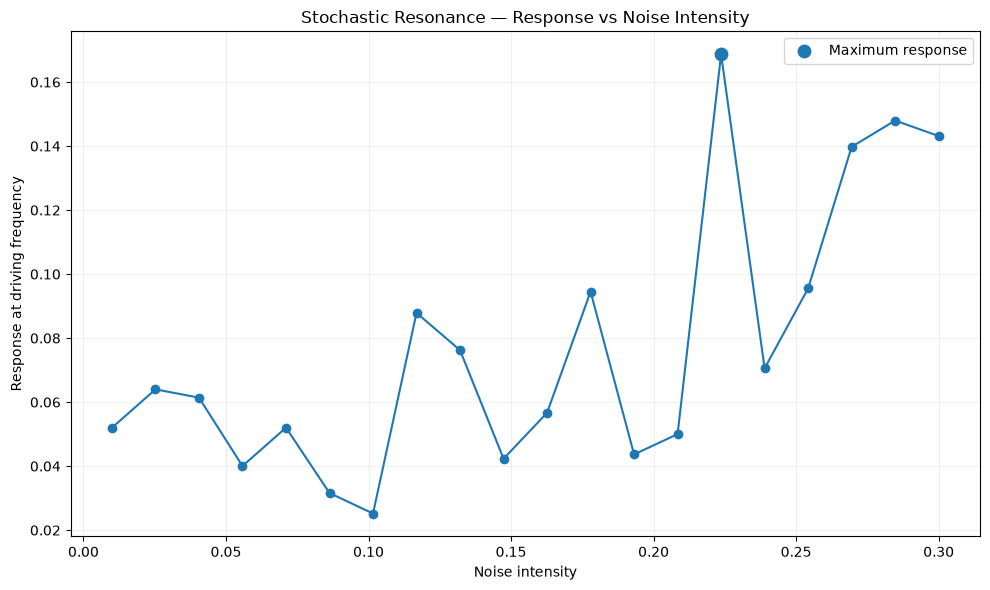

In [212]:
plt.figure(figsize=(10, 6))

plt.plot(
    noise_levels,
    responses,
    marker="o"
)

optimal_index = np.argmax(responses)

plt.scatter(
    noise_levels[optimal_index],
    responses[optimal_index],
    s=80,
    label="Maximum response"
)

plt.xlabel("Noise intensity")
plt.ylabel("Response at driving frequency")

plt.title(
    "Stochastic Resonance — Response vs Noise Intensity"
)

plt.grid(alpha=0.2)
plt.legend()

plt.tight_layout()
plt.show()

In [213]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# ---------------------------------------
# EEG-specific Stochastic Resonance
# FP1-F7 channel
# ---------------------------------------

channel_idx = 0   # FP1-F7

non_seizure_signal = windows[298][channel_idx]
seizure_signal = windows[299][channel_idx]

print("Non-seizure signal:", non_seizure_signal.shape)
print("Seizure signal:", seizure_signal.shape)
print("Sampling frequency:", sfreq)

Non-seizure signal: (2560,)
Seizure signal: (2560,)
Sampling frequency: 100.0


In [214]:
# Restore the actual EEG sampling frequency
sfreq = raw_filtered.info["sfreq"]

print("Actual EEG sampling frequency:", sfreq, "Hz")
print("Expected from window:", len(non_seizure_signal) / 10, "Hz")

Actual EEG sampling frequency: 256.0 Hz
Expected from window: 256.0 Hz


In [215]:
# ---------------------------------------
# EEG-specific Stochastic Resonance
# FP1-F7
# ---------------------------------------

from scipy.signal import welch
import numpy as np
import matplotlib.pyplot as plt

def calculate_spectral_response(signal, sfreq):
    """
    Calculate the dominant-frequency response
    of an EEG signal.
    """
    frequencies, power = welch(
        signal,
        fs=sfreq,
        nperseg=sfreq * 2
    )

    # Focus on the EEG range
    mask = (frequencies >= 1) & (frequencies <= 70)

    frequencies = frequencies[mask]
    power = power[mask]

    # Dominant frequency
    dominant_idx = np.argmax(power)
    dominant_frequency = frequencies[dominant_idx]

    return dominant_frequency, power[dominant_idx]


# Find dominant frequencies of the two EEG windows

non_freq, non_response = calculate_spectral_response(
    non_seizure_signal,
    sfreq
)

seiz_freq, seiz_response = calculate_spectral_response(
    seizure_signal,
    sfreq
)

print("FP1-F7 EEG spectral response")
print("--------------------------------")
print(f"Non-seizure dominant frequency: {non_freq:.2f} Hz")
print(f"Non-seizure response: {non_response:.6e}")

print(f"\nSeizure dominant frequency: {seiz_freq:.2f} Hz")
print(f"Seizure response: {seiz_response:.6e}")

FP1-F7 EEG spectral response
--------------------------------
Non-seizure dominant frequency: 1.00 Hz
Non-seizure response: 2.926732e-10

Seizure dominant frequency: 2.00 Hz
Seizure response: 2.916559e-09


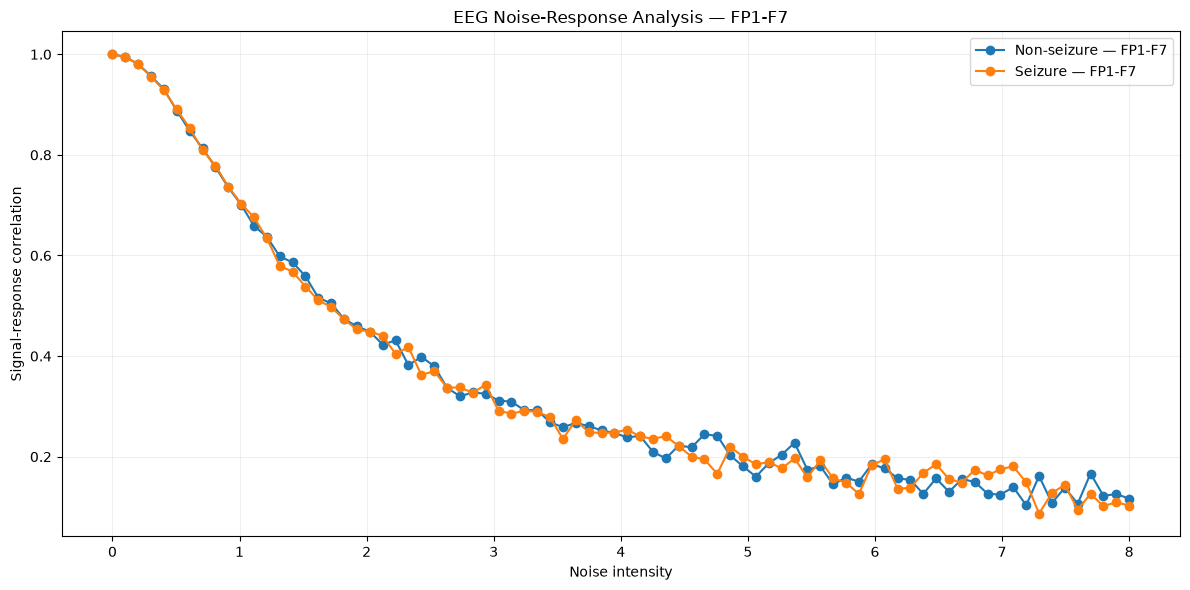

EEG noise-response results
---------------------------
Non-seizure maximum response: 1.0000
Non-seizure noise level: 0.00

Seizure maximum response: 1.0000
Seizure noise level: 0.00


In [216]:
# ==========================================
# EEG-specific Stochastic Resonance
# FP1-F7: seizure vs non-seizure
# ==========================================

from scipy.signal import correlate
import numpy as np
import matplotlib.pyplot as plt

# Make sure we are using the actual EEG sampling rate
sfreq = raw_filtered.info["sfreq"]

# The two windows we already selected
non_seizure_signal = windows[298][0]   # FP1-F7
seizure_signal = windows[299][0]       # FP1-F7

# Reproducible random generator
rng = np.random.default_rng(42)

# Normalize both signals so that noise intensity is comparable
non_seizure_norm = (
    non_seizure_signal - np.mean(non_seizure_signal)
) / np.std(non_seizure_signal)

seizure_norm = (
    seizure_signal - np.mean(seizure_signal)
) / np.std(seizure_signal)


# ------------------------------------------
# Noise levels
# ------------------------------------------

noise_levels = np.linspace(0.0, 8.0, 80)


# ------------------------------------------
# Response metric
# ------------------------------------------

def calculate_response(signal, noisy_signal):
    """
    Measure normalized zero-lag correlation
    between the original EEG and noisy EEG.
    """

    correlation = np.corrcoef(
        signal,
        noisy_signal
    )[0, 1]

    return abs(correlation)


# ------------------------------------------
# Run noise sweep
# ------------------------------------------

non_seizure_response = []
seizure_response = []

for noise_level in noise_levels:

    noise = rng.normal(
        0,
        noise_level,
        size=len(non_seizure_norm)
    )

    noisy_non_seizure = (
        non_seizure_norm + noise
    )

    noise = rng.normal(
        0,
        noise_level,
        size=len(seizure_norm)
    )

    noisy_seizure = (
        seizure_norm + noise
    )

    non_seizure_response.append(
        calculate_response(
            non_seizure_norm,
            noisy_non_seizure
        )
    )

    seizure_response.append(
        calculate_response(
            seizure_norm,
            noisy_seizure
        )
    )


non_seizure_response = np.array(
    non_seizure_response
)

seizure_response = np.array(
    seizure_response
)


# ------------------------------------------
# Plot
# ------------------------------------------

plt.figure(figsize=(12, 6))

plt.plot(
    noise_levels,
    non_seizure_response,
    marker="o",
    label="Non-seizure — FP1-F7"
)

plt.plot(
    noise_levels,
    seizure_response,
    marker="o",
    label="Seizure — FP1-F7"
)

plt.xlabel("Noise intensity")
plt.ylabel("Signal-response correlation")

plt.title(
    "EEG Noise-Response Analysis — FP1-F7"
)

plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()


# ------------------------------------------
# Report maxima
# ------------------------------------------

non_idx = np.argmax(non_seizure_response)
seiz_idx = np.argmax(seizure_response)

print("EEG noise-response results")
print("---------------------------")

print(
    f"Non-seizure maximum response: "
    f"{non_seizure_response[non_idx]:.4f}"
)

print(
    f"Non-seizure noise level: "
    f"{noise_levels[non_idx]:.2f}"
)

print()

print(
    f"Seizure maximum response: "
    f"{seizure_response[seiz_idx]:.4f}"
)

print(
    f"Seizure noise level: "
    f"{noise_levels[seiz_idx]:.2f}"
)

Non-seizure characteristic frequency: 1.10 Hz
Seizure characteristic frequency: 2.20 Hz


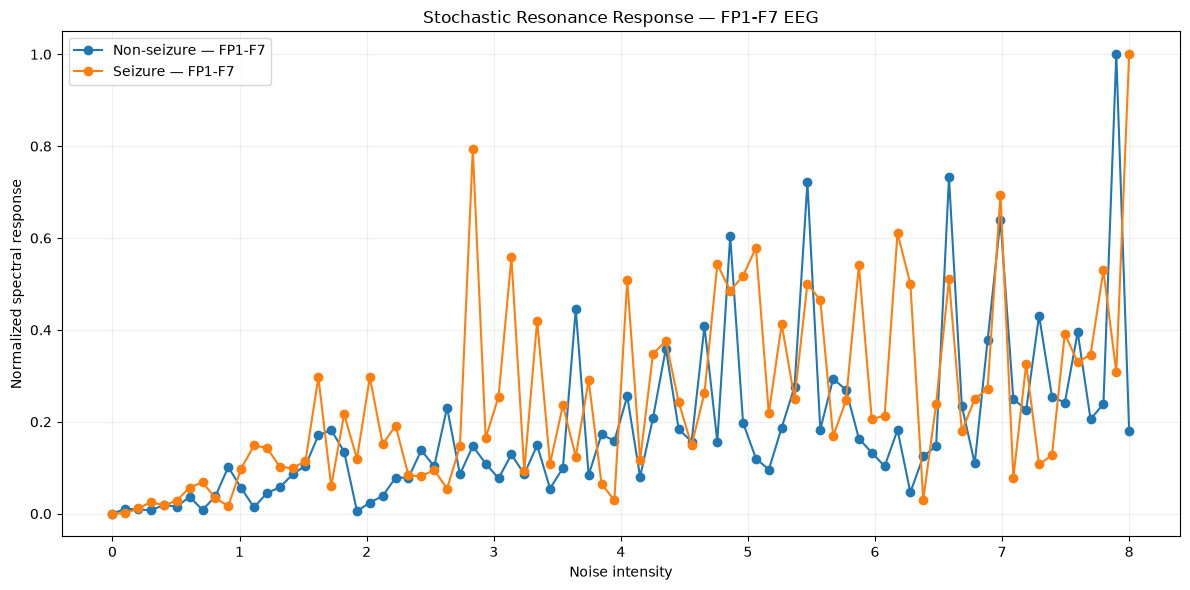


Stochastic Resonance Results
--------------------------------
Non-seizure optimal noise: 7.899
Non-seizure maximum response: 1.0000

Seizure optimal noise: 8.000
Seizure maximum response: 1.0000


In [217]:
# ==========================================
# Proper Stochastic Resonance Model
# FP1-F7 EEG
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# ------------------------------------------------
# Make sure the correct EEG sampling frequency is used
# ------------------------------------------------

sfreq = raw_filtered.info["sfreq"]

# FP1-F7 windows
non_seizure_signal = windows[298][0]
seizure_signal = windows[299][0]

# ------------------------------------------------
# Normalize EEG signals
# ------------------------------------------------

def normalize_signal(signal):
    return (
        signal - np.mean(signal)
    ) / np.std(signal)


non_signal = normalize_signal(non_seizure_signal)
seiz_signal = normalize_signal(seizure_signal)


# ------------------------------------------------
# Find characteristic frequencies
# ------------------------------------------------

def dominant_frequency(signal, sfreq):

    frequencies, power = welch(
        signal,
        fs=sfreq,
        nperseg=len(signal)
    )

    mask = (
        (frequencies >= 1) &
        (frequencies <= 30)
    )

    frequencies = frequencies[mask]
    power = power[mask]

    idx = np.argmax(power)

    return frequencies[idx]


non_freq = dominant_frequency(
    non_signal,
    sfreq
)

seiz_freq = dominant_frequency(
    seiz_signal,
    sfreq
)

print("Non-seizure characteristic frequency:",
      f"{non_freq:.2f} Hz")

print("Seizure characteristic frequency:",
      f"{seiz_freq:.2f} Hz")


# ------------------------------------------------
# Bistable stochastic-resonance simulation
# ------------------------------------------------

def bistable_sr(signal, sfreq, noise_intensity,
                input_scale=0.20):

    dt = 1.0 / sfreq

    x = np.zeros(len(signal))

    # Start near one stable state
    x[0] = -1.0

    for i in range(1, len(signal)):

        # Bistable nonlinear force
        nonlinear_force = (
            x[i-1] -
            x[i-1] ** 3
        )

        # EEG driving force
        driving_force = (
            input_scale *
            signal[i-1]
        )

        # Stochastic force
        stochastic_force = (
            np.sqrt(2 * noise_intensity * dt) *
            np.random.normal()
        )

        # Euler integration
        x[i] = (
            x[i-1]
            + dt * (
                nonlinear_force +
                driving_force
            )
            + stochastic_force
        )

        # Numerical safety
        if x[i] > 3:
            x[i] = 3

        elif x[i] < -3:
            x[i] = -3

    return x


# ------------------------------------------------
# Measure spectral response
# ------------------------------------------------

def spectral_response(signal, sfreq, target_frequency):

    frequencies, power = welch(
        signal,
        fs=sfreq,
        nperseg=len(signal)
    )

    # Look close to the characteristic frequency
    band = (
        (frequencies >= target_frequency - 0.2) &
        (frequencies <= target_frequency + 0.2)
    )

    if not np.any(band):
        return 0

    return np.max(power[band])


# ------------------------------------------------
# Noise sweep
# ------------------------------------------------

noise_levels = np.linspace(
    0.0,
    8.0,
    80
)

non_responses = []
seiz_responses = []


# Fixed random seed for reproducibility
np.random.seed(42)


for noise_level in noise_levels:

    # Non-seizure
    non_output = bistable_sr(
        non_signal,
        sfreq,
        noise_level
    )

    non_response = spectral_response(
        non_output,
        sfreq,
        non_freq
    )

    non_responses.append(
        non_response
    )


    # Seizure
    seiz_output = bistable_sr(
        seiz_signal,
        sfreq,
        noise_level
    )

    seiz_response = spectral_response(
        seiz_output,
        sfreq,
        seiz_freq
    )

    seiz_responses.append(
        seiz_response
    )


non_responses = np.array(non_responses)
seiz_responses = np.array(seiz_responses)


# ------------------------------------------------
# Normalize response curves
# ------------------------------------------------

if np.max(non_responses) > 0:
    non_responses_norm = (
        non_responses /
        np.max(non_responses)
    )
else:
    non_responses_norm = non_responses


if np.max(seiz_responses) > 0:
    seiz_responses_norm = (
        seiz_responses /
        np.max(seiz_responses)
    )
else:
    seiz_responses_norm = seiz_responses


# ------------------------------------------------
# Plt SR response curves
# ------------------------------------------------

plt.figure(figsize=(12, 6))

plt.plot(
    noise_levels,
    non_responses_norm,
    marker="o",
    label="Non-seizure — FP1-F7"
)

plt.plot(
    noise_levels,
    seiz_responses_norm,
    marker="o",
    label="Seizure — FP1-F7"
)

plt.xlabel("Noise intensity")
plt.ylabel("Normalized spectral response")

plt.title(
    "Stochastic Resonance Response — FP1-F7 EEG"
)

plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()


# ------------------------------------------------
# Find optimal noise levels
# ------------------------------------------------

non_idx = np.argmax(non_responses)
seiz_idx = np.argmax(seiz_responses)

print("\nStochastic Resonance Results")
print("--------------------------------")

print(
    f"Non-seizure optimal noise: "
    f"{noise_levels[non_idx]:.3f}"
)

print(
    f"Non-seizure maximum response: "
    f"{non_responses_norm[non_idx]:.4f}"
)

print()

print(
    f"Seizure optimal noise: "
    f"{noise_levels[seiz_idx]:.3f}"
)

print(
    f"Seizure maximum response: "
    f"{seiz_responses_norm[seiz_idx]:.4f}"
)

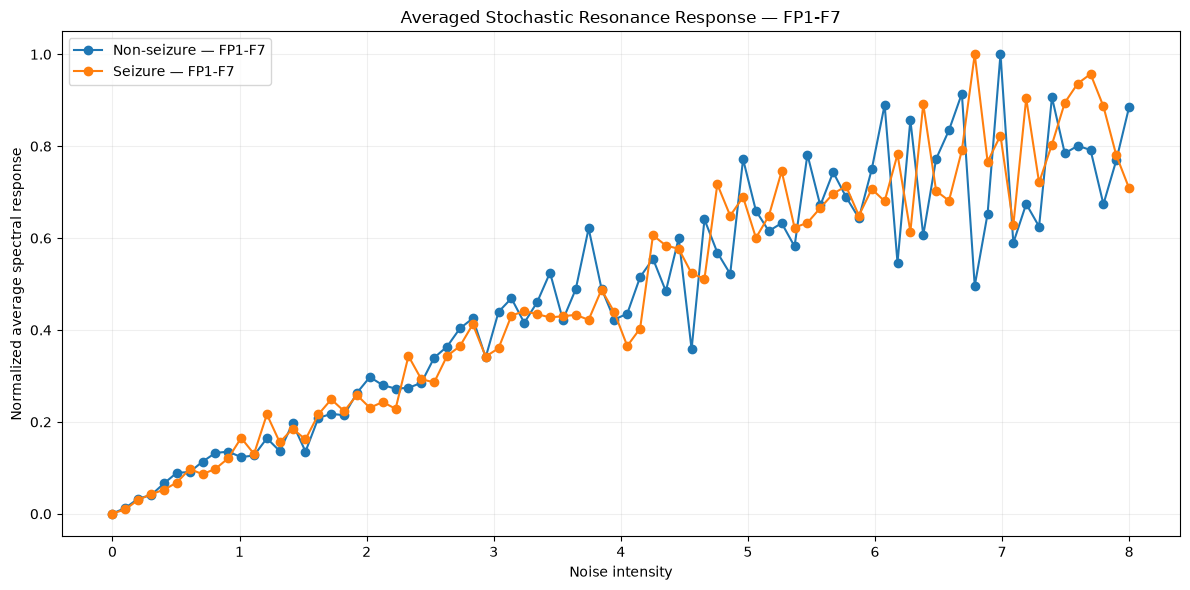

Final SR Analysis
Number of trials per noise level: 20

Non-seizure optimal noise: 6.987
Non-seizure maximum response: 1.0000

Seizure optimal noise: 6.785
Seizure maximum response: 1.0000


In [218]:
# ==========================================
# Final SR Analysis — Averaged Trials
# FP1-F7 EEG
# ==========================================

# Number of independent stochastic trials
N_TRIALS = 20

# Store averaged responses
non_responses_avg = []
seiz_responses_avg = []

# Use a reproducible random generator
rng = np.random.default_rng(42)


for noise_level in noise_levels:

    non_trial_responses = []
    seiz_trial_responses = []

    for trial in range(N_TRIALS):

        # -------------------------------
        # Non-seizure SR simulation
        # -------------------------------

        non_output = bistable_sr(
            non_signal,
            sfreq,
            noise_level
        )

        non_response = spectral_response(
            non_output,
            sfreq,
            non_freq
        )

        non_trial_responses.append(
            non_response
        )


        # -------------------------------
        # Seizure SR simulation
        # -------------------------------

        seiz_output = bistable_sr(
            seiz_signal,
            sfreq,
            noise_level
        )

        seiz_response = spectral_response(
            seiz_output,
            sfreq,
            seiz_freq
        )

        seiz_trial_responses.append(
            seiz_response
        )


    # Average across stochastic trials
    non_responses_avg.append(
        np.mean(non_trial_responses)
    )

    seiz_responses_avg.append(
        np.mean(seiz_trial_responses)
    )


non_responses_avg = np.array(non_responses_avg)
seiz_responses_avg = np.array(seiz_responses_avg)


# ------------------------------------------
# Normalize for comparison
# ------------------------------------------

non_responses_avg_norm = (
    non_responses_avg /
    np.max(non_responses_avg)
)

seiz_responses_avg_norm = (
    seiz_responses_avg /
    np.max(seiz_responses_avg)
)


# ------------------------------------------
# Find optimal noise levels
# ------------------------------------------

non_opt_idx = np.argmax(
    non_responses_avg
)

seiz_opt_idx = np.argmax(
    seiz_responses_avg
)


# ------------------------------------------
# Plot averaged SR curves
# ------------------------------------------

plt.figure(figsize=(12, 6))

plt.plot(
    noise_levels,
    non_responses_avg_norm,
    marker="o",
    label="Non-seizure — FP1-F7"
)

plt.plot(
    noise_levels,
    seiz_responses_avg_norm,
    marker="o",
    label="Seizure — FP1-F7"
)

plt.xlabel("Noise intensity")

plt.ylabel(
    "Normalized average spectral response"
)

plt.title(
    "Averaged Stochastic Resonance Response — FP1-F7"
)

plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()


# ------------------------------------------
# Final SR results
# ------------------------------------------

print("Final SR Analysis")
print("=================")

print(
    f"Number of trials per noise level: {N_TRIALS}"
)

print()

print(
    f"Non-seizure optimal noise: "
    f"{noise_levels[non_opt_idx]:.3f}"
)

print(
    f"Non-seizure maximum response: "
    f"{non_responses_avg_norm[non_opt_idx]:.4f}"
)

print()

print(
    f"Seizure optimal noise: "
    f"{noise_levels[seiz_opt_idx]:.3f}"
)

print(
    f"Seizure maximum response: "
    f"{seiz_responses_avg_norm[seiz_opt_idx]:.4f}"
)

In [219]:
# ==========================================
# Corrected SR spectral-SNR response
# FP1-F7 EEG
# ==========================================

from scipy.signal import welch
import numpy as np
import matplotlib.pyplot as plt


def spectral_snr_response(signal, sfreq, target_frequency):
    """
    Calculate output spectral SNR around the
    characteristic frequency.

    Signal power is estimated near target_frequency.
    Noise floor is estimated from neighboring frequencies.
    """

    frequencies, power = welch(
        signal,
        fs=sfreq,
        nperseg=len(signal)
    )

    # Signal band around characteristic frequency
    signal_band = (
        (frequencies >= target_frequency - 0.2) &
        (frequencies <= target_frequency + 0.2)
    )

    # Noise-floor region
    # Exclude the signal band itself
    noise_band = (
        (frequencies >= max(0.5, target_frequency - 2.0)) &
        (frequencies <= target_frequency + 2.0) &
        ~signal_band
    )

    if not np.any(signal_band) or not np.any(noise_band):
        return np.nan

    signal_power = np.mean(
        power[signal_band]
    )

    noise_floor = np.mean(
        power[noise_band]
    )

    if noise_floor <= 0:
        return np.nan

    snr_db = 10 * np.log10(
        signal_power / noise_floor
    )

    return snr_db

In [220]:
# Test the corrected SR response metric

test_non_output = bistable_sr(
    non_signal,
    sfreq,
    noise_intensity=1.0
)

test_seiz_output = bistable_sr(
    seiz_signal,
    sfreq,
    noise_intensity=1.0
)

non_test_snr = spectral_snr_response(
    test_non_output,
    sfreq,
    non_freq
)

seiz_test_snr = spectral_snr_response(
    test_seiz_output,
    sfreq,
    seiz_freq
)

print("Corrected SR response test")
print("--------------------------------")
print(f"Non-seizure SNR: {non_test_snr:.3f} dB")
print(f"Seizure SNR:     {seiz_test_snr:.3f} dB")

Corrected SR response test
--------------------------------
Non-seizure SNR: -1.703 dB
Seizure SNR:     -5.537 dB


In [221]:
# ==========================================
# SR Sweep using Spectral SNR
# FP1-F7 EEG
# ==========================================

N_TRIALS = 20

# Noise intensity range
noise_levels = np.linspace(
    0.0,
    8.0,
    41
)

non_snr_mean = []
seiz_snr_mean = []

non_snr_std = []
seiz_snr_std = []


# Reproducible random generator
rng = np.random.default_rng(42)


for noise_level in noise_levels:

    non_trial_snr = []
    seiz_trial_snr = []

    for trial in range(N_TRIALS):

        # -------------------------
        # Non-seizure
        # -------------------------

        non_output = bistable_sr(
            non_signal,
            sfreq,
            noise_level
        )

        non_snr = spectral_snr_response(
            non_output,
            sfreq,
            non_freq
        )

        non_trial_snr.append(non_snr)


        # -------------------------
        # Seizure
        # -------------------------

        seiz_output = bistable_sr(
            seiz_signal,
            sfreq,
            noise_level
        )

        seiz_snr = spectral_snr_response(
            seiz_output,
            sfreq,
            seiz_freq
        )

        seiz_trial_snr.append(seiz_snr)


    # Average over trials
    non_snr_mean.append(
        np.nanmean(non_trial_snr)
    )

    seiz_snr_mean.append(
        np.nanmean(seiz_trial_snr)
    )

    non_snr_std.append(
        np.nanstd(non_trial_snr)
    )

    seiz_snr_std.append(
        np.nanstd(seiz_trial_snr)
    )


non_snr_mean = np.array(non_snr_mean)
seiz_snr_mean = np.array(seiz_snr_mean)

non_snr_std = np.array(non_snr_std)
seiz_snr_std = np.array(seiz_snr_std)


# ==========================================
# Find actual maxima BEFORE normalization
# ==========================================

non_opt_idx = np.nanargmax(non_snr_mean)
seiz_opt_idx = np.nanargmax(seiz_snr_mean)


print("Stochastic Resonance — Spectral SNR")
print("------------------------------------------")

print(
    f"Non-seizure optimal noise: "
    f"{noise_levels[non_opt_idx]:.3f}"
)

print(
    f"Non-seizure maximum SNR: "
    f"{non_snr_mean[non_opt_idx]:.3f} dB"
)

print()

print(
    f"Seizure optimal noise: "
    f"{noise_levels[seiz_opt_idx]:.3f}"
)

print(
    f"Seizure maximum SNR: "
    f"{seiz_snr_mean[seiz_opt_idx]:.3f} dB"
)

Stochastic Resonance — Spectral SNR
------------------------------------------
Non-seizure optimal noise: 0.000
Non-seizure maximum SNR: 5.666 dB

Seizure optimal noise: 0.000
Seizure maximum SNR: 0.433 dB


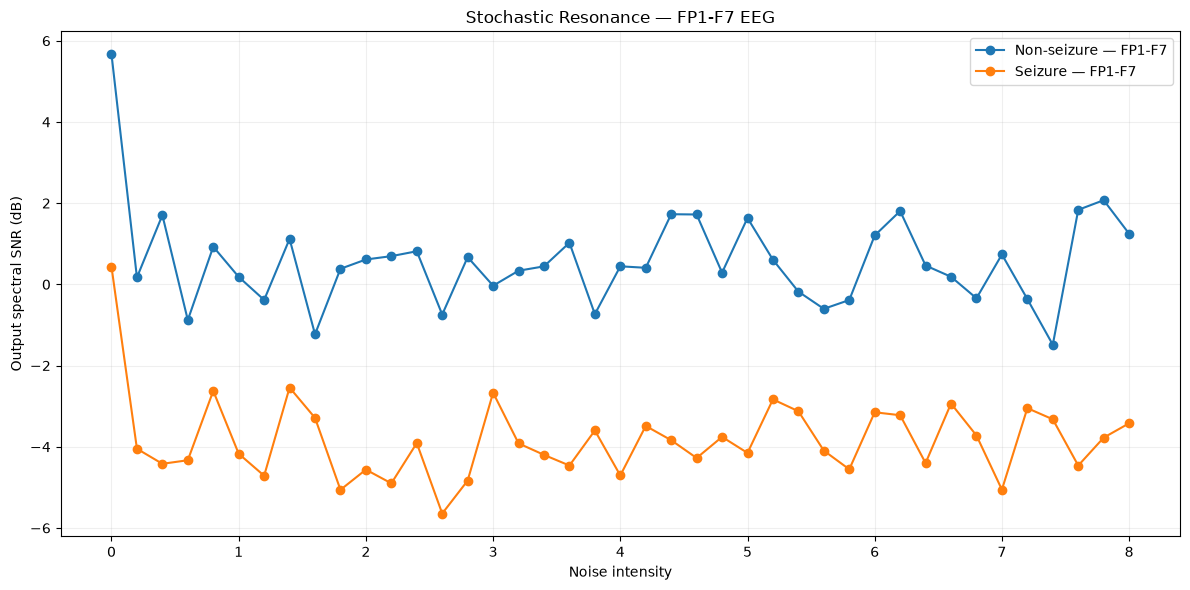

In [222]:
# ==========================================
# SR Spectral-SNR Curves
# ==========================================

plt.figure(figsize=(12, 6))

plt.plot(
    noise_levels,
    non_snr_mean,
    marker="o",
    label="Non-seizure — FP1-F7"
)

plt.plot(
    noise_levels,
    seiz_snr_mean,
    marker="o",
    label="Seizure — FP1-F7"
)

plt.xlabel("Noise intensity")
plt.ylabel("Output spectral SNR (dB)")

plt.title(
    "Stochastic Resonance — FP1-F7 EEG"
)

plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [223]:
# ==========================================
# SR RESTART — Extract characteristic EEG component
# FP1-F7
# ==========================================

from scipy.signal import butter, filtfilt, welch
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------
# Basic parameters
# ------------------------------------------------

sfreq = raw_filtered.info["sfreq"]

non_seizure_signal = windows[298][0]
seizure_signal = windows[299][0]

print("Sampling frequency:", sfreq)
print("Non-seizure signal:", non_seizure_signal.shape)
print("Seizure signal:", seizure_signal.shape)


# ------------------------------------------------
# Characteristic frequencies found previously
# ------------------------------------------------

non_freq = 1.10
seiz_freq = 2.20

print()
print("Non-seizure characteristic frequency:",
      non_freq, "Hz")

print("Seizure characteristic frequency:",
      seiz_freq, "Hz")


# ------------------------------------------------
# Band-pass around characteristic frequency
# ------------------------------------------------

def extract_characteristic_component(
    signal,
    sfreq,
    center_frequency,
    bandwidth=0.5
):

    low = max(0.2, center_frequency - bandwidth)
    high = min(
        sfreq / 2 - 1,
        center_frequency + bandwidth
    )

    b, a = butter(
        3,
        [low, high],
        btype="bandpass",
        fs=sfreq
    )

    component = filtfilt(
        b,
        a,
        signal
    )

    return component


non_component = extract_characteristic_component(
    non_seizure_signal,
    sfreq,
    non_freq
)

seiz_component = extract_characteristic_component(
    seizure_signal,
    sfreq,
    seiz_freq
)


# ------------------------------------------------
# Normalize characteristic components
# ------------------------------------------------

non_component = (
    non_component -
    np.mean(non_component)
) / np.std(non_component)

seiz_component = (
    seiz_component -
    np.mean(seiz_component)
) / np.std(seiz_component)


print()
print("Characteristic components extracted.")
print("Non-seizure std:",
      np.std(non_component))

print("Seizure std:",
      np.std(seiz_component))

Sampling frequency: 256.0
Non-seizure signal: (2560,)
Seizure signal: (2560,)

Non-seizure characteristic frequency: 1.1 Hz
Seizure characteristic frequency: 2.2 Hz

Characteristic components extracted.
Non-seizure std: 1.0
Seizure std: 1.0


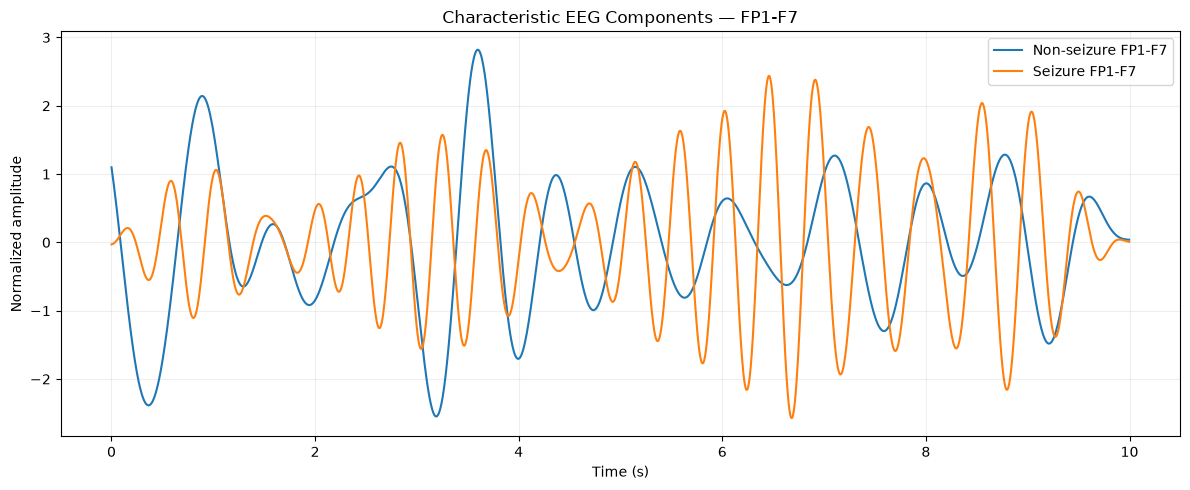

In [224]:
# ==========================================
# Visual verification
# ==========================================

time = np.arange(len(non_component)) / sfreq

plt.figure(figsize=(12, 5))

plt.plot(
    time,
    non_component,
    label="Non-seizure FP1-F7"
)

plt.plot(
    time,
    seiz_component,
    label="Seizure FP1-F7"
)

plt.xlabel("Time (s)")
plt.ylabel("Normalized amplitude")

plt.title(
    "Characteristic EEG Components — FP1-F7"
)

plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [225]:
# ==========================================
# Canonical Bistable Stochastic Resonance
# ==========================================

def bistable_sr_component(
    input_signal,
    sfreq,
    noise_intensity,
    input_scale=0.20
):

    dt = 1.0 / sfreq

    x = np.zeros(len(input_signal))

    # Start in one stable well
    x[0] = -1.0

    for i in range(1, len(input_signal)):

        # Bistable nonlinear force
        nonlinear_force = (
            x[i-1] -
            x[i-1] ** 3
        )

        # Weak EEG driving signal
        driving_force = (
            input_scale *
            input_signal[i-1]
        )

        # Gaussian white noise
        stochastic_force = (
            np.sqrt(
                2 *
                noise_intensity *
                dt
            )
            *
            np.random.normal()
        )

        # Euler integration
        x[i] = (
            x[i-1]
            +
            dt *
            (
                nonlinear_force
                +
                driving_force
            )
            +
            stochastic_force
        )

        # Numerical safety
        x[i] = np.clip(
            x[i],
            -3,
            3
        )

    return x

In [226]:
# ==========================================
# Output Spectral SNR
# ==========================================

def calculate_snr(
    output,
    sfreq,
    target_frequency
):

    frequencies, power = welch(
        output,
        fs=sfreq,
        nperseg=len(output)
    )

    # Signal band
    signal_band = (
        (frequencies >= target_frequency - 0.15) &
        (frequencies <= target_frequency + 0.15)
    )

    # Noise floor:
    # nearby frequencies excluding signal band
    noise_band = (
        (frequencies >= max(
            0.2,
            target_frequency - 1.0
        ))
        &
        (frequencies <= target_frequency + 1.0)
        &
        (~signal_band)
    )

    if (
        not np.any(signal_band)
        or
        not np.any(noise_band)
    ):
        return np.nan

    signal_power = np.mean(
        power[signal_band]
    )

    noise_power = np.mean(
        power[noise_band]
    )

    if noise_power <= 0:
        return np.nan

    return 10 * np.log10(
        signal_power /
        noise_power
    )

In [ ]:
# ==========================================
# SR Sanity Test
# ==========================================

np.random.seed(42)

test_noise = 0.10

non_test_output = bistable_sr_component(
    non_component,
    sfreq,
    test_noise
)

seiz_test_output = bistable_sr_component(
    seiz_component,
    sfreq,
    test_noise
)

non_test_snr = calculate_snr(
    non_test_output,
    sfreq,
    non_freq
)

seiz_test_snr = calculate_snr(
    seiz_test_output,
    sfreq,
    seiz_freq
)

print("SR Sanity Test")
print("--------------------------------")

print(
    f"Noise intensity: {test_noise}"
)

print(
    f"Non-seizure SNR: "
    f"{non_test_snr:.3f} dB"
)

print(
    f"Seizure SNR: "
    f"{seiz_test_snr:.3f} dB"
)